FUNDAMENTOS DE MINERAÇÃO DE DADOS

Modelagem de dados: Florestas Aleatórias (22/10)

Dataset: Abalone (https://archive.ics.uci.edu/dataset/1/abalone)

Aluna: Gisele Fonseca

Data: 22 de outubro

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [10]:
# Carregando o dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
colunas = ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight',
           'VisceraWeight', 'ShellWeight', 'Rings']
df = pd.read_csv(url, header=None, names=colunas)

# Exibe as 5 primeiras linhas
df.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


# 1 - Crie uma variável categórica em outra tabela para separar moluscos velhos e jovens pela média.

In [11]:
# Calcula a média do número de anéis
media_aneis = df['Rings'].mean()

# Cria nova variável categórica
df['Categoria_Idade'] = np.where(df['Rings'] >= media_aneis, 'Velho', 'Jovem')

# Cria uma nova tabela apenas com a categoria e o número de anéis
tabela_idade = df[['Rings', 'Categoria_Idade']]
tabela_idade.head()


,Rings,Categoria_Idade
0,15,Velho
1,7,Jovem
2,9,Jovem
3,10,Velho
4,7,Jovem


# 2 - Use X como características e y (número de anéis) como variável objetivo para ajustar uma árvore de decisão para estimar o número de aneis dos moluscos.

In [12]:
# Transformando a variável categórica 'Sex' em dummies
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

# Definindo X e y
X = df.drop(columns=['Rings', 'Categoria_Idade'])
y = df['Rings']

# Exibe as dimensões
X.shape, y.shape


((4177, 9), (4177,))

### Demonstração: Regressor para os números de anéis  (Teste prático antes da separação treino e teste)


In [20]:
# Importando novamente o DecisionTreeRegressor
from sklearn import tree
import numpy as np

# Criação e treino do modelo em TODO o conjunto de dados (sem separação)
clf = tree.DecisionTreeRegressor()
clf = clf.fit(X, y)

# Calcula o erro (diferença entre previsão e valor real)
# Se o resultado for um array de zeros, significa que o modelo memorizou os dados (overfitting)
clf.predict(X) - y.to_numpy().squeeze()


array([0., 0., 0., ..., 0., 0., 0.])

In [21]:
# Cálculo da taxa de acerto exata (1.0 = 100% das previsões idênticas aos valores reais)
# Essa métrica é apenas ilustrativa, pois o modelo foi avaliado sobre os mesmos dados usados no treino
np.sum(clf.predict(X) == y.to_numpy().squeeze()) / y.shape[0]


np.float64(1.0)

**Interpretação:**
O resultado 1.0 mostra que a árvore de decisão acertou 100% dos casos,
mas isso ocorre porque o modelo foi avaliado com os mesmos dados usados para o treinamento.
Na prática, isso representa um caso clássico de **overfitting**.
Por isso, nas próximas etapas faremos a separação entre amostras de treino e teste.


# 3 - Use uma técnica de amostragem para separar as amostras em treinamento e teste a taxas de 70% e 30%.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)


Tamanho do conjunto de treino: (2923, 9)
Tamanho do conjunto de teste: (1254, 9)


## 4 - Calcule a acurácia nos dois conjuntos.



In [14]:
# Cria e treina o modelo
modelo = DecisionTreeRegressor(random_state=42)
modelo.fit(X_train, y_train)

# Predições
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Cálculo da acurácia (R²)
acc_train = r2_score(y_train, y_pred_train)
acc_test = r2_score(y_test, y_pred_test)

print(f"Acurácia no treino: {acc_train:.3f}")
print(f"Acurácia no teste: {acc_test:.3f}")


Acurácia no treino: 1.000
Acurácia no teste: 0.143


## 5 - Mude o critério de qualidade da divisão e gere os mesmos dois valores de acurácia.


In [15]:
# Alterando o critério de divisão (para absolute_error)
modelo_alt = DecisionTreeRegressor(criterion='absolute_error', random_state=42)
modelo_alt.fit(X_train, y_train)

# Predições
y_pred_train_alt = modelo_alt.predict(X_train)
y_pred_test_alt = modelo_alt.predict(X_test)

# Cálculo da acurácia (R²)
acc_train_alt = r2_score(y_train, y_pred_train_alt)
acc_test_alt = r2_score(y_test, y_pred_test_alt)

print(f"Acurácia (critério absolute_error) no treino: {acc_train_alt:.3f}")
print(f"Acurácia (critério absolute_error) no teste: {acc_test_alt:.3f}")


Acurácia (critério absolute_error) no treino: 1.000
Acurácia (critério absolute_error) no teste: 0.095


## 6 - Gere uma tabela de acurácia sobre os conjuntos de teste amostragem variando o parâmetro do número mínimo de amostras para divisão entre 1 e 20.


,min_samples_split,Acuracia_Teste
0,2,0.143462
1,3,0.125831
2,4,0.128792
3,5,0.198926
4,6,0.221885
5,7,0.237523
6,8,0.258661
7,9,0.246430
8,10,0.301658
9,11,0.312663


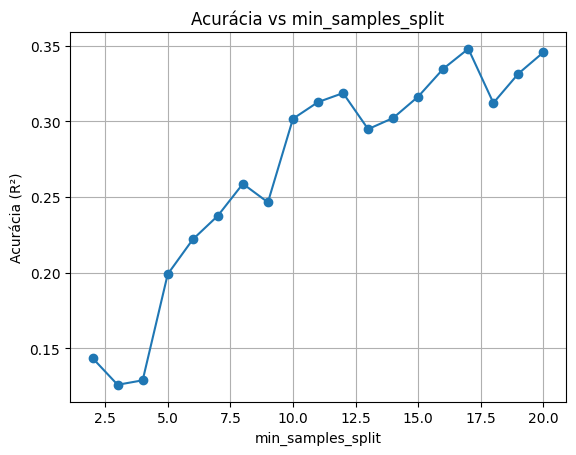

In [18]:
resultados_split = []

for n in range(2, 21):  # começa no 2
    model = DecisionTreeRegressor(min_samples_split=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = r2_score(y_test, y_pred)
    resultados_split.append((n, acc))

df_split = pd.DataFrame(resultados_split, columns=['min_samples_split', 'Acuracia_Teste'])
display(df_split)

plt.plot(df_split['min_samples_split'], df_split['Acuracia_Teste'], marker='o')
plt.title('Acurácia vs min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('Acurácia (R²)')
plt.grid(True)
plt.show()

## 7 - Repita a geração da tabela variando o parâmetro de número de características usadas na divisão entre 1 e todas.


,max_features,Acuracia_Teste
0,1,0.065952
1,2,0.054172
2,3,0.033832
3,4,0.079145
4,5,0.122258
5,6,0.173775
6,7,0.109929
7,8,0.140478
8,9,0.143462


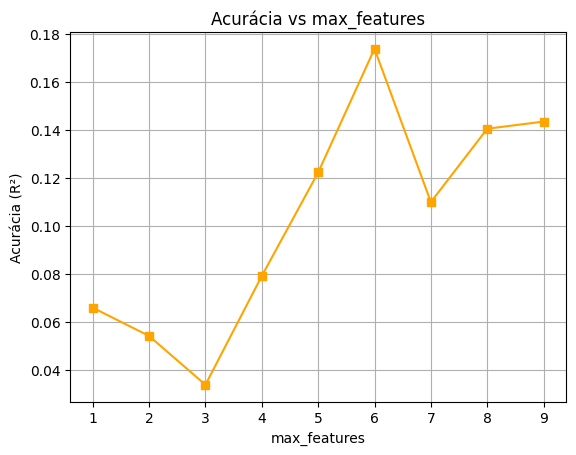

In [19]:
n_features = X.shape[1]
resultados_feat = []

for n in range(1, n_features + 1):
    model = DecisionTreeRegressor(max_features=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = r2_score(y_test, y_pred)
    resultados_feat.append((n, acc))

df_feat = pd.DataFrame(resultados_feat, columns=['max_features', 'Acuracia_Teste'])
display(df_feat)

plt.plot(df_feat['max_features'], df_feat['Acuracia_Teste'], marker='s', color='orange')
plt.title('Acurácia vs max_features')
plt.xlabel('max_features')
plt.ylabel('Acurácia (R²)')
plt.grid(True)
plt.show()
